In [1]:
import os

SEED = 42

# PYTHONHASHSEED:
os.environ['PYTHONHASHSEED'] = str(SEED)

import random
import numpy as np
import pandas as pd
import tensorflow as tf

def set_seed(seed=SEED):
    
    random.seed(seed)
    
    np.random.seed(seed)
    
    tf.random.set_seed(seed)
    
    print(f"Global Seed Set: {seed}")

# Call the function immediately to apply the configuration
set_seed(SEED)


Global Seed Set: 42


In [17]:
# Set local file paths
path_data1 = r'C:\Users\asadi\OneDrive\Desktop\Phishi link\Data\phishing_site_urls.csv'
path_data2 = r'C:\Users\asadi\OneDrive\Desktop\Phishi link\Data\phishing_url_dataset_unique.csv'
path_data3 = './Data/PhiUSIIL_Phishing_URL_Dataset.csv'

print(f'data1: {path_data1}')
print(f'data2: {path_data2}')
print(f'data3: {path_data3}')


data1: C:\Users\asadi\OneDrive\Desktop\Phishi link\Data\phishing_site_urls.csv
data2: C:\Users\asadi\OneDrive\Desktop\Phishi link\Data\phishing_url_dataset_unique.csv
data3: ./Data/PhiUSIIL_Phishing_URL_Dataset.csv


In [18]:
if os.path.exists(path_data1):
    # top-1m.csv has no header and contains only rank and URL.
    df_data1 = pd.read_csv(path_data1, header=None, names=['Rank', 'URL'])
    df_data1['Label'] = 0
    df_data1 = df_data1[['URL', 'Label']]
else:
    print(f"Warning: {path_data1} not found. Proceeding with empty df_data1.")
    df_data1 = pd.DataFrame(columns=['URL', 'Label'])

df_data2 = pd.read_csv(path_data2)
df_data3 = pd.read_csv(path_data3)


In [19]:
if not df_data1.empty:
    df_data1['Label'] = df_data1['Label'].apply(lambda x: 1 if x == 'bad' else 0)
    print(df_data1.head())
else:
    print("df_data1 is empty.")


     URL  Label
0  Label      0
1    bad      0
2    bad      0
3    bad      0
4    bad      0


In [20]:
df_data2.drop(columns='source', inplace=True)
df_data2.head()

,url,label
0,http://110.37.26.193:54956/bin.sh,1
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1
2,https://d6gu.ripple-cask.ru/jid43vpd,1
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1
4,https://bronze.systems,0


In [21]:
df_data3 = df_data3.rename(columns={'label': 'Label'})
df_data3 = df_data3[['URL', 'Label']]

# Invert PhiUSIIL labels to match our schema (1 = Phishing, 0 = Legitimate)
# The original dataset encodes Legit: 1 and Phishing: 0
df_data3['Label'] = 1 - df_data3['Label']

df_data3.head()

,URL,Label
0,https://www.southbankmosaics.com,0
1,https://www.uni-mainz.de,0
2,https://www.voicefmradio.co.uk,0
3,https://www.sfnmjournal.com,0
4,https://www.rewildingargentina.org,0


In [22]:
if not df_data1.empty:
    print(df_data1.isnull().sum().sum())
else:
    print("df_data1 is empty: 0 nulls.")


0


In [23]:
if not df_data1.empty:
    print(df_data1['Label'].value_counts())
else:
    print("df_data1 is empty: no label counts.")


Label
0    549347
Name: count, dtype: int64


In [24]:
df_data2.rename(columns={'url': 'URL'}, inplace=True)
df_data2.rename(columns={'label': 'Label'}, inplace=True)

In [25]:
df_data2.isnull().sum().sum()

np.int64(0)

In [26]:
df_data2['Label'].value_counts()
# 1:phishing
# 0: legit

Label
1    24406
0    24406
Name: count, dtype: int64

In [27]:
df_data3['Label'].value_counts()
# 1:phishing
# 0: legit

Label
0    134850
1    100945
Name: count, dtype: int64

In [28]:
df_data3.isnull().sum().sum()

np.int64(0)

In [29]:
import re
import urllib.parse

# PRE-COMPILED REGEX PATTERNS (Performance Optimization)
_PROTOCOL_RE = re.compile(r'^([a-zA-Z0-9+.-]+://|//)')
_SCHEME_RE = re.compile(r'^([a-zA-Z][a-zA-Z0-9+.-]*)://')
_WWW_RE = re.compile(r'^www\d*\.')
_DOMAIN_PATH_RE = re.compile(r'^([^/?#]+)([/?#].*)?$')

def _with_scheme(url: str) -> str:
    url = str(url).strip()
    if '://' in url:
        return url
    if url.startswith('//'):
        return 'http:' + url
    return 'http://' + url

def normalize_hostname(hostname: str, *, strip_www: bool = True) -> str:
    """Normalize host-only values without removing meaningful path/query data."""
    normalized = str(hostname or '').strip().lower().rstrip('.')
    if strip_www:
        normalized = _WWW_RE.sub('', normalized)
    return normalized

def extract_hostname(url: str) -> str:
    """Return hostname without userinfo, port, trailing dot, or a leading www variant."""
    try:
        parsed = urllib.parse.urlsplit(_with_scheme(url))
    except ValueError:
        return ''
    return normalize_hostname(parsed.hostname or '')

def _strip_hostname_trailing_dot(domain: str) -> str:
    userinfo, at, hostport = domain.rpartition('@')
    prefix = f'{userinfo}{at}' if at else ''

    if hostport.startswith('['):
        return domain

    host, colon, port = hostport.rpartition(':')
    if colon and port.isdigit():
        return f'{prefix}{host.rstrip(".")}{colon}{port}'
    return f'{prefix}{hostport.rstrip(".")}'

def _strip_default_port(domain: str, scheme: str) -> str:
    default_ports = {'http': '80', 'https': '443'}
    default_port = default_ports.get(scheme)
    if not default_port:
        return domain

    hostpart, colon, port = domain.rpartition(':')
    if colon and port == default_port:
        return hostpart
    return domain

def _strip_empty_url_markers(rest: str) -> str:
    if rest.startswith('/?') or rest.startswith('/#'):
        rest = rest[1:]

    if rest in {'/', '?', '#', '?#'}:
        return ''

    if rest.startswith('?#'):
        rest = rest[1:]

    if rest.endswith('?') or rest.endswith('#'):
        rest = rest[:-1]

    return rest

def clean_url(url: str) -> str:
    """
    Normalize URL noise that does not carry routing or payload information.
    Preserves path, query values, fragments with content, and non-default ports.
    """
    url = str(url).strip()
    scheme_match = _SCHEME_RE.match(url)
    scheme = scheme_match.group(1).lower() if scheme_match else ''

    url = _PROTOCOL_RE.sub('', url)
    url = _WWW_RE.sub('', url)

    match = _DOMAIN_PATH_RE.match(url)
    if match:
        domain = _strip_hostname_trailing_dot(match.group(1).lower())
        domain = _strip_default_port(domain, scheme)
        rest = _strip_empty_url_markers(match.group(2) if match.group(2) else '')
        return domain + rest

    return url.lower()


In [31]:
import urllib.parse

SHORTENER_DOMAINS = {
    'bit.ly', 'tinyurl.com', 't.co', 'goo.gl', 'ow.ly', 'is.gd',
    'buff.ly', 'adf.ly', 'bit.do', 'cutt.ly', 'v.gd', 'j.mp'
}

def is_short(url):
    try:
        value = str(url).strip()
        if not value.startswith(('http://', 'https://')):
            value = 'http://' + value
        parsed = urllib.parse.urlsplit(value)
        domain = normalize_hostname(parsed.hostname or '')
        return domain in SHORTENER_DOMAINS
    except Exception:
        return False


In [32]:
import base64
import ipaddress
import re
import urllib.parse

"""
URL SANITIZATION & SEMANTIC MASKING PIPELINE FOR CHARACTER-LEVEL TENSORFLOW MODELS

The preprocessor masks high-entropy, sample-specific URL parts before inference:

1. Intermediate form: semantic tags with repeat counts, e.g. <TOKEN:32>.
2. Char stream: each tag expands to a rare character repeated by count for Conv1D.

This 1D TensorFlow notebook is intentionally character-level only; no subword or word stream is used.
"""

# Semantic tags are expanded to rare characters for the TensorFlow char-level Conv1D model.
# The values are escaped to keep this source file encoding-stable on Windows.
TAG_CHAR_MAP = {
    "IPV4": "\u03b1",
    "IPV6": "\u03b2",
    "MAC_ADDRESS": "\u03b3",
    "DATE": "\u03b4",
    "NUMERIC_ID": "\u03b5",
    "HEX_ID": "\u03b6",
    "UUID_FORMAT": "\u03b7",
    "JWT_FORMAT": "\u03b8",
    "HASH_FORMAT": "\u03bb",
    "ETH_WALLET": "\u03bc",
    "BTC_WALLET": "\u03c0",
    "EMAIL_MATCH": "\u03c1",
    "EMAIL_MISMATCH": "\u03c3",
    "BASE64_EXTERNAL": "\u03c4",
    "BASE64_FORMAT": "\u03c6",
    "SESSION_ID": "\u03c8",
    "TOKEN": "\u03c9",
    "OTP_CODE": "\u0394",
    "OAUTH_PARAM": "\u0398",
    "OAUTH_CLIENT": "\u039b",
    "FILE_EXEC": "\u039e",
    "FILE_MACRO": "\u03a0",
    "FILE_ID": "\u03a3",
    "FILE_NAME": "\u03a6",
    "REF_EXTERNAL": "\u03a8",
    "REF_ENCODED": "\u03a9",
    "REF_INTERNAL": "\u2207",
    "REF_DOMAIN": "\u2135",
    "REF_OTHER": "\u2111",
    "TIMESTAMP": "\u211c",
    "IP_PARAM": "\u2118",
    "ID": "\u212e",
    "EMPTY": "\u2205",
    "DEFAULT": "\u221e",
}

FIXED_LENGTH_TAGS = frozenset(
    {
        "IPV4",
        "IPV6",
        "MAC_ADDRESS",
        "DATE",
        "TIMESTAMP",
        "ETH_WALLET",
        "BTC_WALLET",
    }
)

MAX_TAG_REPEAT = 512
_TAG_RE = re.compile(r"<([A-Z0-9_]+):(\d+)>")


# 0. URL/HOST HELPERS
_HOST_RE = re.compile(
    r"^(?P<scheme>[a-zA-Z][a-zA-Z0-9+.-]*://|//)?"
    r"(?P<host>\[[^\]]+\]|[^/?#:]+)"
    r"(?P<rest>.*)$"
)
_OBF_DEC_RE = re.compile(r"^\d{8,10}$")
_OBF_HEX_RE = re.compile(r"^0[xX][0-9a-fA-F]{6,8}$")
_OBF_OCT_RE = re.compile(r"^(?:0[0-7]+\.){3}0[0-7]+$")


def _extract_host(url: str) -> str:
    """Extract hostname from either full URLs or cleaned scheme-less URLs."""
    if not isinstance(url, str):
        return ""

    candidate = url.strip()
    if not candidate:
        return ""

    try:
        parsed = urllib.parse.urlsplit(candidate if "://" in candidate or candidate.startswith("//") else f"//{candidate}")
        host = parsed.hostname
        if host:
            return normalize_hostname(host)
    except ValueError:
        pass

    fallback = candidate.split("/", 1)[0].split("?", 1)[0].split("#", 1)[0]
    if fallback.startswith("[") and "]" in fallback:
        return fallback[1 : fallback.index("]")].lower()
    return normalize_hostname(fallback.split(":", 1)[0])


def _int_to_ipv4(value: int) -> str | None:
    if 0 <= value <= 0xFFFFFFFF:
        return ".".join(str((value >> shift) & 255) for shift in (24, 16, 8, 0))
    return None


def _decode_obfuscated_ipv4_host(host: str) -> str | None:
    raw = host.strip("[]")
    try:
        if _OBF_DEC_RE.fullmatch(raw):
            return _int_to_ipv4(int(raw, 10))
        if _OBF_HEX_RE.fullmatch(raw):
            return _int_to_ipv4(int(raw, 16))
        if _OBF_OCT_RE.fullmatch(raw):
            octets = [int(part, 8) for part in raw.split(".")]
            if all(0 <= octet <= 255 for octet in octets):
                return ".".join(str(octet) for octet in octets)
    except (ValueError, OverflowError):
        return None
    return None


def _normalize_obfuscated_ip(url: str) -> str:
    """Normalize decimal/hex/octal IPv4 host obfuscation without touching path values."""
    match = _HOST_RE.match(url)
    if not match:
        return url

    decoded = _decode_obfuscated_ipv4_host(match.group("host"))
    if not decoded:
        return url

    scheme = match.group("scheme") or ""
    return f"{scheme}{decoded}{match.group('rest')}"


# 1. HELPER PATTERNS
_SEG_END = r"(?=[&#/?]|$)"
_QS_END = r"(?=[&#]|$)"
_RANDOM_VALUE = (
    r"("
    r"\d{4,}"
    r"|(?=[^\s&#]*\d)[a-fA-F0-9]{8,}"
    r"|(?=[^\s&#]*[a-zA-Z])(?=[^\s&#]*\d)[a-zA-Z0-9\-]{8,}"
    r")"
)

_IPV4_RE = r"(?:(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)"
_IPV6_CANDIDATE_RE = re.compile(r"(?<![A-Za-z0-9])\[?((?:[0-9a-fA-F]{0,4}:){2,7}[0-9a-fA-F]{0,4})\]?(?![A-Za-z0-9])")


# 2. VALUE_BASED_RULES
VALUE_BASED_RULES = {
    "<IPV4>": re.compile(rf"\b{_IPV4_RE}\b"),
    "<MAC_ADDRESS>": re.compile(r"(\b)((?:[0-9a-fA-F]{2}[:-]){5}[0-9a-fA-F]{2})(?=\b)"),
    "<DATE>": re.compile(r"(\b|/)((?:19|20)\d{2}[-/.](?:0[1-9]|1[0-2])[-/.](?:0[1-9]|[12]\d|3[01]))(?=\b|/|$)"),
    "<NUMERIC_ID>": re.compile(r"(/)(\d{6,})(?=/|[?#]|$)"),
    "<HEX_ID>": re.compile(r"(/)([\da-fA-F]{15,})(?=/|[?#]|$)"),
    "<ETH_WALLET>": re.compile(r"(\b)(0x[\da-fA-F]{40})(?=\b)"),
    "<BTC_WALLET>": re.compile(r"([?&/=])(bc1[a-zA-HJ-NP-Z0-9]{25,39}|[13][a-km-zA-HJ-NP-Z1-9]{25,34})" + _SEG_END),
    "<UUID_FORMAT>": re.compile(r"([?&][^=]+=|/)([\da-fA-F]{8}-[\da-fA-F]{4}-[\da-fA-F]{4}-[\da-fA-F]{4}-[\da-fA-F]{12})" + _SEG_END),
    "<JWT_FORMAT>": re.compile(r"([?&][^=]+=|/)(eyJ[a-zA-Z0-9_-]+\.[a-zA-Z0-9_-]+\.[a-zA-Z0-9_-]+)" + _SEG_END),
    "<HASH_FORMAT>": re.compile(r"([?&][^=]+=|/)([\da-fA-F]{32}|[\da-fA-F]{40}|[\da-fA-F]{64})" + _SEG_END),
    "<EMAIL>": re.compile(r"([?&][^=]+=)([a-zA-Z0-9_.%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,})" + _QS_END),
    "<BASE64_FORMAT>": re.compile(r"([?&][^=]+=)([a-zA-Z0-9_+/\-]{20,}={0,2})" + _QS_END),
}


# 3. NAME_BASED_RULES
NAME_BASED_RULES = {
    "<SESSION_ID>": re.compile(r"([?&](?:session|sid|sessionid|PHPSESSID|JSESSIONID)=)" + _RANDOM_VALUE + _QS_END, re.IGNORECASE),
    "<TOKEN>": re.compile(r"([?&](?:token|access_token|auth|api_key|key|secret|bearer)=)" + _RANDOM_VALUE + _QS_END, re.IGNORECASE),
    "<OTP_CODE>": re.compile(r"([?&](?:otp|pin|passcode|verification_code|confirm_code|verif_code|2fa|mfa|one_time_password|auth_code)=)(\d{4,8})" + _QS_END, re.IGNORECASE),
    "<OAUTH_PARAM>": re.compile(r"([?&](?:code|state|nonce|sig|signature)=)" + _RANDOM_VALUE + _QS_END, re.IGNORECASE),
    "<OAUTH_CLIENT>": re.compile(r"([?&](?:client_id|app_id|consumer_key)=)" + _RANDOM_VALUE + _QS_END, re.IGNORECASE),
    "<TIMESTAMP>": re.compile(r"([?&](?:timestamp|ts|time|date|t|_t)=)(\d{8,15}|(?:19|20)\d{2}[-/.T](?:0[1-9]|1[0-2])[-/.](?:0[1-9]|[12]\d|3[01])(?:[T ]\d{2}:\d{2}(?::\d{2})?)?)" + _QS_END, re.IGNORECASE),
    "<IP_PARAM>": re.compile(r"([?&](?:ip|ip_address|remote_addr|client_ip)=)(localhost|" + _IPV4_RE + r"|(?:[a-fA-F0-9]{1,4}:){2,7}[a-fA-F0-9]{0,4}|\d{7,10})" + _QS_END, re.IGNORECASE),
    "<ID>": re.compile(r"([?&](?:id|uid|[a-z_]*_id)=)(\d{4,}|(?=[^\s&#]*\d)[a-fA-F0-9]{10,})" + _QS_END, re.IGNORECASE),
    "<REF>": re.compile(r"([?&](?:ref|reference|referrer|returnUrl|next|redirect|redirect_uri|url|return|goto|dest|destination)=)([^&#]*)", re.IGNORECASE),
    "<FILE_PARAM>": re.compile(r"([?&](?:file|doc|document|download|dl|attachment|attach|asset)=)([^&#]*)", re.IGNORECASE),
}

_VALUE_ORDER = [
    "<MAC_ADDRESS>",
    "<ETH_WALLET>",
    "<BTC_WALLET>",
    "<UUID_FORMAT>",
    "<JWT_FORMAT>",
    "<HASH_FORMAT>",
    "<BASE64_FORMAT>",
    "<EMAIL>",
    "<HEX_ID>",
    "<NUMERIC_ID>",
]


# 4. CLASSIFIER HELPERS
_EXTERNAL_SCHEME_RE = re.compile(r"^(?:https?://|//|/\\|\\\\|javascript:|data:|vbscript:)", re.IGNORECASE)
_ENCODED_EXT_RE = re.compile(r"(?:https?%3A|%2F%2F|javascript%3A|data%3A|vbscript%3A)", re.IGNORECASE)
_DOUBLE_ENCODED_RE = re.compile(r"(?:https?%253A|%252F%252F|javascript%253A|data%253A|vbscript%253A)", re.IGNORECASE)
_BARE_DOMAIN_RE = re.compile(r"^[a-zA-Z0-9][a-zA-Z0-9\-]*(?:\.[a-zA-Z0-9][a-zA-Z0-9\-]*)+\.[a-zA-Z]{2,}(?:[:/]|$)", re.IGNORECASE)

_EXEC_EXTS = frozenset(
    {
        ".exe",
        ".bat",
        ".cmd",
        ".ps1",
        ".vbs",
        ".wsf",
        ".hta",
        ".jar",
        ".class",
        ".sh",
        ".bash",
        ".py",
        ".rb",
        ".php",
        ".dll",
        ".scr",
        ".pif",
        ".msi",
        ".dmg",
        ".pkg",
        ".deb",
        ".rpm",
        ".zip",
        ".rar",
        ".7z",
        ".tar",
        ".gz",
        ".bz2",
        ".iso",
        ".img",
        ".jse",
        ".vbe",
    }
)
_MACRO_EXTS = frozenset({".doc", ".docm", ".xls", ".xlsm", ".ppt", ".pptm"})

_EMAIL_ECOSYSTEMS = {
    "google": frozenset({"gmail", "google", "googlemail"}),
    "gmail": frozenset({"gmail", "google", "googlemail"}),
    "microsoft": frozenset({"microsoft", "outlook", "live", "msn", "hotmail"}),
    "outlook": frozenset({"microsoft", "outlook", "live", "msn", "hotmail"}),
    "live": frozenset({"microsoft", "outlook", "live", "msn", "hotmail"}),
    "office": frozenset({"microsoft", "outlook", "live", "msn", "hotmail"}),
    "yahoo": frozenset({"yahoo"}),
    "apple": frozenset({"icloud", "apple"}),
    "icloud": frozenset({"icloud", "apple"}),
}


def _unquote_twice(value: str) -> str:
    decoded = urllib.parse.unquote(value).strip()
    return urllib.parse.unquote(decoded).strip() if "%" in decoded else decoded


def _decode_base64_text(value: str) -> str:
    padded = value + "=" * (-len(value) % 4)
    for altchars in (b"-_", None):
        try:
            raw = base64.b64decode(padded.encode("ascii"), altchars=altchars, validate=True)
            return raw.decode("utf-8", errors="ignore")
        except Exception:
            continue
    return ""


def _file_extension(value: str) -> str:
    decoded = _unquote_twice(value).lower()
    filename = decoded.rsplit("/", 1)[-1].rsplit("\\", 1)[-1]
    filename = re.sub(r"[?#].*", "", filename)
    if "." not in filename:
        return ""
    return "." + filename.rsplit(".", 1)[-1]


def _is_existing_tag(value: str) -> bool:
    return bool(_TAG_RE.fullmatch(value))


# 5. REPLACER FACTORY (Intermediate Tagging)
def get_replacer(mask_tag, url_domain=""):
    base_tag = mask_tag[1:-1]
    is_fixed = base_tag in FIXED_LENGTH_TAGS
    domain = (url_domain or "").lower()

    def replacer(match):
        prefix = match.group(1)
        target = match.group(2)

        if not target:
            return f"{prefix}<EMPTY:1>"
        if _is_existing_tag(target):
            return match.group(0)

        tag_name = base_tag
        multiplier = 1 if is_fixed else len(target)

        if mask_tag == "<REF>":
            decoded = _unquote_twice(target)
            decoded_b64 = _decode_base64_text(target).strip()
            multiplier = len(decoded) if decoded else len(target)

            if _DOUBLE_ENCODED_RE.search(target) or _ENCODED_EXT_RE.search(target) or _EXTERNAL_SCHEME_RE.match(decoded_b64):
                tag_name = "REF_ENCODED"
            elif _EXTERNAL_SCHEME_RE.match(decoded):
                tag_name = "REF_EXTERNAL"
            elif decoded.startswith("/"):
                tag_name = "REF_INTERNAL"
            elif _BARE_DOMAIN_RE.match(decoded):
                tag_name = "REF_DOMAIN"
            else:
                tag_name = "REF_OTHER"

        elif mask_tag == "<BASE64_FORMAT>":
            decoded_b64 = _decode_base64_text(target)
            if _EXTERNAL_SCHEME_RE.match(decoded_b64.strip()):
                tag_name = "BASE64_EXTERNAL"

        elif mask_tag == "<EMAIL>":
            email_domain = target.split("@")[-1].lower() if "@" in target else ""
            url_main = ".".join(domain.split(".")[-2:]) if domain else ""
            email_main = ".".join(email_domain.split(".")[-2:])
            is_match = bool(url_main and email_main == url_main)

            if not is_match:
                for url_kw, email_kws in _EMAIL_ECOSYSTEMS.items():
                    if url_kw in domain and any(email_kw in email_domain for email_kw in email_kws):
                        is_match = True
                        break

            tag_name = "EMAIL_MATCH" if is_match else "EMAIL_MISMATCH"

        elif mask_tag == "<FILE_PARAM>":
            ext = _file_extension(target)
            if ext in _EXEC_EXTS:
                tag_name = "FILE_EXEC"
            elif ext in _MACRO_EXTS:
                tag_name = "FILE_MACRO"
            elif not ext and re.fullmatch(r"[a-zA-Z0-9_\-]{8,}", target):
                tag_name = "FILE_ID"
            else:
                tag_name = "FILE_NAME"

        return f"{prefix}<{tag_name}:{multiplier}>"

    return replacer


# 6. STATIC REPLACER CACHE
_STATIC_REPLACERS = {"<DATE>": get_replacer("<DATE>")}

for _tag in _VALUE_ORDER:
    if _tag != "<EMAIL>":
        _STATIC_REPLACERS[_tag] = get_replacer(_tag)

for _tag in NAME_BASED_RULES:
    _STATIC_REPLACERS[_tag] = get_replacer(_tag)


def _mask_ipv6_candidates(text: str) -> str:
    def replacer(match):
        candidate = match.group(1)
        try:
            ipaddress.IPv6Address(candidate)
        except ValueError:
            return match.group(0)
        return "<IPV6:1>"

    return _IPV6_CANDIDATE_RE.sub(replacer, text)


# 7. SANITIZE_URL (Generates Intermediate String)
def sanitize_url(url):
    if not isinstance(url, str) or len(url) < 4:
        return url

    masked = _normalize_obfuscated_ip(url.strip())
    url_domain = _extract_host(masked)

    masked = VALUE_BASED_RULES["<IPV4>"].sub("<IPV4:1>", masked)
    masked = _mask_ipv6_candidates(masked)
    masked = VALUE_BASED_RULES["<DATE>"].sub(_STATIC_REPLACERS["<DATE>"], masked)

    for mask_tag, pattern in NAME_BASED_RULES.items():
        masked = pattern.sub(_STATIC_REPLACERS[mask_tag], masked)

    for mask_tag in _VALUE_ORDER:
        replacer = get_replacer(mask_tag, url_domain) if mask_tag == "<EMAIL>" else _STATIC_REPLACERS[mask_tag]
        masked = VALUE_BASED_RULES[mask_tag].sub(replacer, masked)

    return masked


# 8. CHARACTER STREAM
def to_char_stream(url):
    """Convert a cleaned URL into the only stream consumed by Linear-1D_ResNetSE."""
    intermediate_url = sanitize_url(url)

    if not isinstance(intermediate_url, str):
        return url

    def char_mapper(match):
        tag_name = match.group(1)
        multiplier = min(int(match.group(2)), MAX_TAG_REPEAT)
        char = TAG_CHAR_MAP.get(tag_name, TAG_CHAR_MAP["DEFAULT"])
        return char * multiplier

    return _TAG_RE.sub(char_mapper, intermediate_url)


In [33]:
# Clean URL
if not df_data1.empty:
    df_data1['URL'] = df_data1['URL'].apply(lambda x: clean_url(x))
    print(df_data1.head())
else:
    print("df_data1 is empty.")


     URL  Label
0  label      0
1    bad      0
2    bad      0
3    bad      0
4    bad      0


In [34]:
# Clean URL
df_data2['URL'] = df_data2['URL'].apply(lambda x: clean_url(x))

print(df_data2.head())

                                                 URL  Label
0                         110.37.26.193:54956/bin.sh      1
1                   sentry5.obor1shwron8.ru/4ylkytvt      1
2                       d6gu.ripple-cask.ru/jid43vpd      1
3  130.12.180.34/596a96cc7bf9108cd896f33c44aedc8a...      1
4                                     bronze.systems      0


In [35]:
# Clean URL
df_data3['URL'] = df_data3['URL'].apply(lambda x: clean_url(x))

print(df_data3.head())

                      URL  Label
0    southbankmosaics.com      0
1            uni-mainz.de      0
2      voicefmradio.co.uk      0
3         sfnmjournal.com      0
4  rewildingargentina.org      0


In [36]:
def prepare_char_frame(frame, split_name, *, already_cleaned=False):
    """Apply the Training-notebook preprocessing, keeping only Char_URL for the model."""
    frame = frame.copy()
    print(f"[*] Initial {split_name} URLs: {len(frame):,}")

    # Match Training-notebook exactly:
    # - df_data1/2/3 are already cleaned in cells 19-21 before aggregation.
    # - Fine-tune/validation/test are cleaned inside their own load cells.
    if not already_cleaned:
        frame['URL'] = frame['URL'].apply(lambda x: clean_url(x))

    # 2. Filter out shortened URLs.
    frame = frame[~frame['URL'].apply(is_short)]
    print(f"[*] {split_name} URLs after removing short-links: {len(frame):,}")

    # 3. Fast raw de-duplication before semantic masking.
    frame = frame.drop_duplicates(subset=['URL'])

    # 4. Apply semantic masking and expand tags to the same Char_URL as Training.split_streams()[0].
    frame['Char_URL'] = frame['URL'].apply(to_char_stream)

    # 5. Structural de-duplication on the exact representation the model sees.
    frame = frame.drop_duplicates(subset=['Char_URL'])
    frame = frame.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f"[*] Final Unique Structural {split_name} URLs: {len(frame):,}")
    return frame


# 1. Aggregate datasets exactly like Training-notebook.
df_train = pd.concat([df_data1, df_data2, df_data3], ignore_index=True)
df_train = prepare_char_frame(df_train, 'Train', already_cleaned=True)
df_train[['URL', 'Char_URL', 'Label']].head()


[*] Initial Train URLs: 833,954
[*] Train URLs after removing short-links: 833,397
[*] Final Unique Structural Train URLs: 269,918


,URL,Char_URL,Label
0,dorasu.com,dorasu.com,0
1,kopin.com,kopin.com,0
2,regular-dear-hyssop.glitch.me,regular-dear-hyssop.glitch.me,1
3,reverent-archimedes.45-81-232-18.plesk.page,reverent-archimedes.45-81-232-18.plesk.page,1
4,weissnatu.ga,weissnatu.ga,1


In [37]:
# Load fine-tuning data
fine_tune_path = './Data/Fine-Tune.csv'
df_fine_tune = pd.read_csv(fine_tune_path)
df_fine_tune = prepare_char_frame(df_fine_tune, 'Fine-Tune')
df_fine_tune[['URL', 'Char_URL', 'Label']].head()


[*] Initial Fine-Tune URLs: 27,205
[*] Fine-Tune URLs after removing short-links: 26,916
[*] Final Unique Structural Fine-Tune URLs: 25,982


,URL,Char_URL,Label
0,vodwka1.weebly.com,vodwka1.weebly.com,1
1,115.63.43.146:35525/bin.sh,α:35525/bin.sh,1
2,kelahealth.com,kelahealth.com,0
3,drdo.gov.in/armaments-research-board/about-us,drdo.gov.in/armaments-research-board/about-us,0
4,sbmt.org.br,sbmt.org.br,0


In [38]:
# Load validation data
val_path = './Data/Validate.csv'
df_final_val = pd.read_csv(val_path)
df_final_val = prepare_char_frame(df_final_val, 'Validation')
df_final_val[['URL', 'Char_URL', 'Label']].head()


[*] Initial Validation URLs: 40,809
[*] Validation URLs after removing short-links: 40,330
[*] Final Unique Structural Validation URLs: 38,620


,URL,Char_URL,Label
0,hospitalsenhedmidt.dk,hospitalsenhedmidt.dk,0
1,edu.pref.shizuoka.jp/kakegawanishi-h/home.nsf/...,edu.pref.shizuoka.jp/kakegawanishi-h/home.nsf/...,0
2,unitedindians.org,unitedindians.org,0
3,cca.fcca.cz/en/currently/,cca.fcca.cz/en/currently/,0
4,tsc-05.ac.jp/eng/,tsc-05.ac.jp/eng/,0


In [39]:
# Load test data
test_path = './Data/Test.csv'
df_test = pd.read_csv(test_path)
df_test = prepare_char_frame(df_test, 'Test')
df_test[['URL', 'Char_URL', 'Label']].head()


[*] Initial Test URLs: 204,045
[*] Test URLs after removing short-links: 201,704
[*] Final Unique Structural Test URLs: 184,432


,URL,Char_URL,Label
0,izet.de/view.php?lng=15&id=72&sub=391,izet.de/view.php?lng=15&id=72&sub=391,0
1,sdams.cn,sdams.cn,0
2,gzsrmyy.com,gzsrmyy.com,0
3,centerforce1.org,centerforce1.org,0
4,altumpharma.com,altumpharma.com,0


In [40]:
# Cross-dataset de-duplication to prevent structural feature leakage.
# Char_URL is the exact representation consumed by the TensorFlow 1D-CNN.
key_column = 'Char_URL'

print(f"Initial sizes: Test={len(df_test):,}, Val={len(df_final_val):,}, FineTune={len(df_fine_tune):,}")

# Remove validation samples that structurally exist in the Test set.
df_final_val = df_final_val[~df_final_val[key_column].isin(df_test[key_column])]

# Remove fine-tuning samples that structurally exist in the Test set.
df_fine_tune = df_fine_tune[~df_fine_tune[key_column].isin(df_test[key_column])]

# Remove fine-tuning samples that structurally exist in the Validation set.
df_fine_tune = df_fine_tune[~df_fine_tune[key_column].isin(df_final_val[key_column])]

print("\n--- RESULTS AFTER CROSS-SET STRUCTURAL FILTERING ---")
print(f"Test set:      {len(df_test):,}")
print(f"Validate set:  {len(df_final_val):,}")
print(f"Fine-tune set: {len(df_fine_tune):,}")


Initial sizes: Test=184,432, Val=38,620, FineTune=25,982

--- RESULTS AFTER CROSS-SET STRUCTURAL FILTERING ---
Test set:      184,432
Validate set:  35,077
Fine-tune set: 23,281


In [41]:
# Prevent feature leakage from pre-training into fine-tune/validation/test splits.
eval_sets = {
    'Fine-Tune': df_fine_tune,
    'Validate': df_final_val,
    'Test': df_test,
}

print(f"[*] Initial Train URLs: {len(df_train):,}\n")

for name, df_eval in eval_sets.items():
    overlap = set(df_train['Char_URL']).intersection(set(df_eval['Char_URL']))
    print(f"[*] Structural overlap with {name} set: {len(overlap):,} patterns")

    if overlap:
        df_train = df_train[~df_train['Char_URL'].isin(overlap)]

print(f"\n[*] Final cleaned Train URLs: {len(df_train):,}")


[*] Initial Train URLs: 269,918

[*] Structural overlap with Fine-Tune set: 4,360 patterns
[*] Structural overlap with Validate set: 6,793 patterns
[*] Structural overlap with Test set: 34,925 patterns

[*] Final cleaned Train URLs: 223,840


   - Mean length: 24.87
   - Longest URL: 6089
   - Percentage of URLs shorter than 250 chars: 99.70%
Train set size after removing noisy URLs: 223168


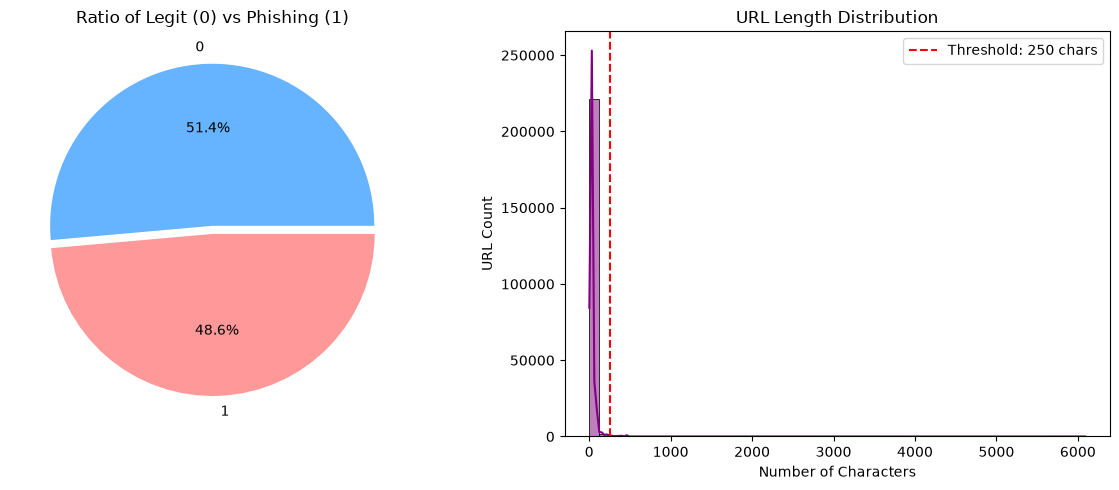

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a single figure for both plots
plt.figure(figsize=(12, 5))

# 1. HISTOGRAM: URL LENGTH DISTRIBUTION (Calculated on unfiltered data)
url_lengths = df_train['URL'].apply(len)

plt.subplot(1, 2, 2)
sns.histplot(url_lengths, bins=50, kde=True, color='purple')
plt.axvline(x=250, color='r', linestyle='--', label='Threshold: 250 chars') # Red threshold line
plt.title('URL Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('URL Count')
plt.legend()

# Quick statistics
print(f"   - Mean length: {url_lengths.mean():.2f}")
print(f"   - Longest URL: {url_lengths.max()}")
print(f"   - Percentage of URLs shorter than 250 chars: {(url_lengths < 250).mean()*100:.2f}%")

# Record initial count
total_before = len(df_train)

# Remove URLs with length > 250 to reduce noise and reset index
df_train = df_train[df_train['URL'].str.len() <= 250].reset_index(drop=True)
total_dropped = total_before - len(df_train)
print(f"Train set size after removing noisy URLs: {len(df_train)}")

# 2. PIE CHART: LABEL RATIO IN TRAIN SET (Calculated on FILTERED data)
plt.subplot(1, 2, 1)
df_train['Label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], explode=(0.05, 0))
plt.title('Ratio of Legit (0) vs Phishing (1)')
plt.ylabel('')

# Adjust layout and display both plots simultaneously
plt.tight_layout()
plt.show()

   - Mean length: 29.64
   - Longest URL: 1193
   - Percentage of URLs shorter than 250 chars: 99.71%
Fine-Tune set size after removing noisy URLs: 23213


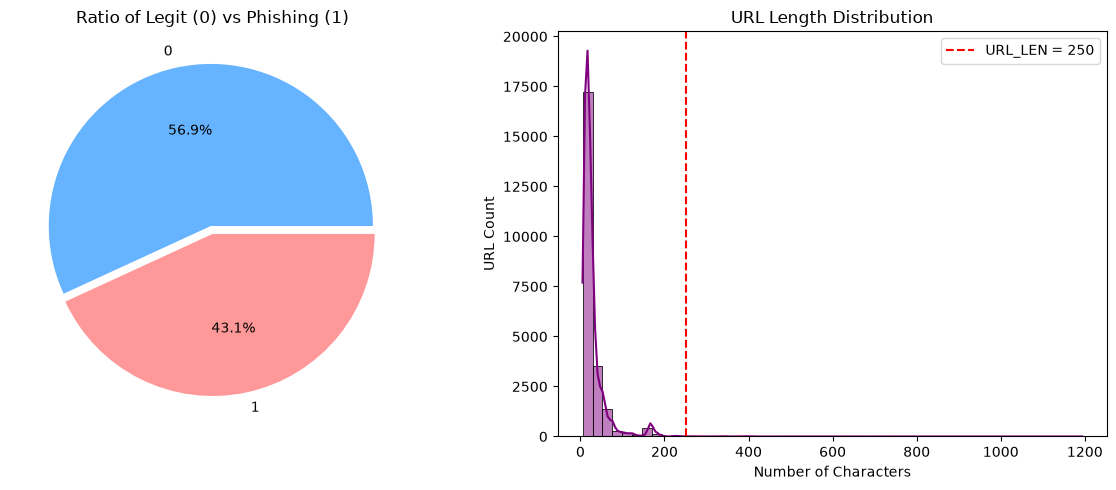

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a single figure for both plots
plt.figure(figsize=(12, 5))

# 1. HISTOGRAM: URL LENGTH DISTRIBUTION (Calculated on unfiltered data)
url_lengths = df_fine_tune['URL'].apply(len)

plt.subplot(1, 2, 2)
sns.histplot(url_lengths, bins=50, kde=True, color='purple')
plt.axvline(x=250, color='r', linestyle='--', label='URL_LEN = 250') # Red threshold line
plt.title('URL Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('URL Count')
plt.legend()

# Quick statistics
print(f"   - Mean length: {url_lengths.mean():.2f}")
print(f"   - Longest URL: {url_lengths.max()}")
print(f"   - Percentage of URLs shorter than 250 chars: {(url_lengths < 250).mean()*100:.2f}%")

# Record initial count
total_before = len(df_fine_tune)

# Remove URLs with length > 250 to reduce noise and reset index
df_fine_tune = df_fine_tune[df_fine_tune['URL'].str.len() <= 250].reset_index(drop=True)
total_dropped = total_before - len(df_fine_tune)
print(f"Fine-Tune set size after removing noisy URLs: {len(df_fine_tune)}")

# 2. PIE CHART: LABEL RATIO IN FINE-TUNE SET (Calculated on FILTERED data)
plt.subplot(1, 2, 1)
df_fine_tune['Label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], explode=(0.05, 0))
plt.title('Ratio of Legit (0) vs Phishing (1)')
plt.ylabel('')

# Adjust layout and display both plots simultaneously
plt.tight_layout()
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

X = df_train['Char_URL']
y = df_train['Label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"[*] Char-level Train: {len(X_train):,} samples")
print(f"[*] Char-level Val:   {len(X_val):,} samples")


[*] Char-level Train: 178,534 samples
[*] Char-level Val:   44,634 samples


In [45]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import numpy as np

# --- CONFIGURATION ---
MAX_LEN = 250

# 1. Prepare character-stream data.
X_train_raw = X_train.astype(str).values
y_train_raw = np.asarray(y_train).astype('float32').reshape(-1, 1)

# 2. Character-level tokenizer.
# Keep every URL character and every semantic-mask character emitted by to_char_stream().
tokenizer = Tokenizer(
    char_level=True,
    oov_token='<OOV>',
    filters='',
    lower=False,
)
tokenizer.fit_on_texts(X_train_raw)

VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f"Char Vocab Size: {VOCAB_SIZE}")

# 3. Convert characters to integer IDs.
sequences = tokenizer.texts_to_sequences(X_train_raw)

# 4. Pad/truncate to the fixed Conv1D length.
X_train = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Example Char_URL: {X_train_raw[0]}")
print(f"Example encoded URL: {X_train[0][:]}")


Char Vocab Size: 115
Example Char_URL: castingup.it
Example encoded URL: [ 6  5  8 12  7 11 18 16 14  4  7 12  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0]


,Split,Column,Mean,Median,P90,P95,P99,Max,Truncated_Ratio
0,train,Char_URL,23.0868,17.0,41.0,63.0,109.0,250,0.0000
1,val,Char_URL,23.1603,17.0,41.0,65.0,109.0,249,0.0000
2,fine_tune,Char_URL,27.1798,17.0,53.0,76.0,167.0,244,0.0000
3,validation,Char_URL,28.1937,17.0,54.0,76.0,170.0,1183,0.0027
4,test,Char_URL,28.1481,16.0,53.0,76.0,170.0,25515,0.0027


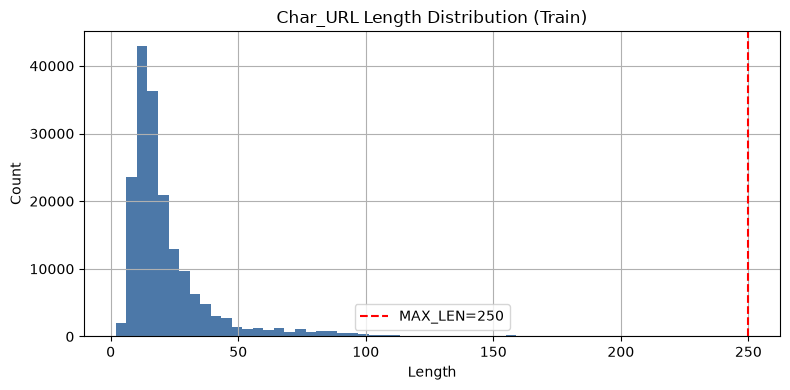

In [46]:
import numpy as np

X_val_raw = X_val.astype(str).values

# Convert character streams to sequences using the tokenizer fitted on the training set.
sequences_val = tokenizer.texts_to_sequences(X_val_raw)

# Padding
X_val = pad_sequences(sequences_val, maxlen=MAX_LEN, padding='post', truncating='post')
y_val_fit = np.asarray(y_val).astype('float32').reshape(-1, 1)


from IPython.display import display as ipy_display
import pandas as pd
import matplotlib.pyplot as plt

def summarize_char_lengths(frame, split_name):
    values = frame['Char_URL'].astype(str).str.len()
    return {
        'Split': split_name,
        'Column': 'Char_URL',
        'Mean': values.mean(),
        'Median': values.median(),
        'P90': values.quantile(0.90),
        'P95': values.quantile(0.95),
        'P99': values.quantile(0.99),
        'Max': values.max(),
        'Truncated_Ratio': (values > MAX_LEN).mean(),
    }

length_rows = [
    summarize_char_lengths(pd.DataFrame({'Char_URL': X_train_raw}), 'train'),
    summarize_char_lengths(pd.DataFrame({'Char_URL': X_val_raw}), 'val'),
    summarize_char_lengths(df_fine_tune, 'fine_tune'),
    summarize_char_lengths(df_final_val, 'validation'),
    summarize_char_lengths(df_test, 'test'),
]

token_length_summary_df = pd.DataFrame(length_rows)
ipy_display(token_length_summary_df.round(4))

plt.figure(figsize=(8, 4))
pd.Series(X_train_raw).astype(str).str.len().clip(upper=MAX_LEN * 2).hist(bins=60, color='#4C78A8')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Char_URL Length Distribution (Train)')
plt.xlabel('Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


In [47]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y):
    y = np.array(y)
    classes = np.unique(y)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    
    class_weight = dict(zip(classes, weights))
    
    return class_weight

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, MaxPooling1D, Dense, Dropout,
    Input, BatchNormalization, SpatialDropout1D, Activation, Add, GlobalAveragePooling1D,
    Concatenate, Reshape, Multiply
)

# Model hyperparameters
EMBED_DIM = 64
BATCH_SIZE = 128
EPOCHS = 40
L2_RATE = 5e-4
SE_RATIO = 16
LABEL_SMOOTHING = 0.05

# Width schedule chosen to keep Linear-1D close to 2.4M parameters.
LINEAR_FILTERS = [64, 128, 256, 512]
LINEAR_KERNELS = [7, 5, 3, 3]
LINEAR_DENSE = [384, 192]

# --- 1. SE BLOCK ---
def se_block(x, ratio=16):
    channels = x.shape[-1]
    reduced = max(channels // ratio, 8)
    squeeze = GlobalAveragePooling1D()(x)
    excitation = Dense(reduced, activation='relu', use_bias=False)(squeeze)
    excitation = Dense(channels, activation='sigmoid', use_bias=False)(excitation)
    excitation = Reshape((1, channels))(excitation)
    return Multiply()([x, excitation])

# --- 2. LINEAR RESIDUAL BLOCK ---
def residual_block(x, filters, kernel_size, dropout_rate=0.0):
    shortcut = x

    x = Conv1D(filters, kernel_size, padding='same',
               kernel_regularizer=l2(L2_RATE),
               kernel_initializer='he_normal',
               use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    x = Conv1D(filters, kernel_size, padding='same',
               kernel_regularizer=l2(L2_RATE),
               kernel_initializer='he_normal',
               use_bias=False)(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, kernel_size=1, padding='same',
                          kernel_regularizer=l2(L2_RATE),
                          kernel_initializer='he_normal',
                          use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = se_block(x, ratio=SE_RATIO)
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

# --- 3. BUILD MODEL: LINEAR STACK ---
inputs = Input(shape=(MAX_LEN,))

x = Embedding(VOCAB_SIZE + 1, EMBED_DIM)(inputs)
x = SpatialDropout1D(0.25)(x)

for block_idx, (filters, kernel_size) in enumerate(zip(LINEAR_FILTERS, LINEAR_KERNELS)):
    x = residual_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dropout_rate=0.05 if block_idx >= 2 else 0.0,
    )
    if block_idx < len(LINEAR_FILTERS) - 1:
        x = MaxPooling1D(pool_size=2)(x)

avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)
x = Concatenate()([avg_pool, max_pool])

for units, dropout_rate in zip(LINEAR_DENSE, [0.4, 0.3]):
    x = Dense(units, kernel_regularizer=l2(L2_RATE), kernel_initializer='he_normal', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs, name="Linear_1D_ResNetSE_2p4M")

# --- 4. CALLBACKS ---
lr_scheduler = ReduceLROnPlateau(
    monitor='val_auc', mode='max', factor=0.5, patience=3,
    min_lr=1e-6, verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_auc', mode='max', patience=7,
    restore_best_weights=True, verbose=1
)

# --- 5. COMPILE & TRAIN ---
weight_dict = get_class_weights(y_train)
print(f"Class Weight penalty for Train set: {weight_dict}")

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')]
)
model.summary()
print(f"[*] Total parameters: {model.count_params():,}")

history = model.fit(
    X_train, y_train_raw,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_fit),
    class_weight=weight_dict,
    callbacks=[lr_scheduler, early_stopping]
)


Class Weight penalty for Train set: {np.int64(0): np.float64(0.9726616980474198), np.int64(1): np.float64(1.028919523271629)}


Model: "Linear_1D_ResNetSE_2p4M"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 64)   │      7,424 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 250, 64)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 250, 64)   │     28,672 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 250, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 250, 64)   │     28,672 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        512 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 250, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 250, 64)   │          0 │ multiply[0][0],   │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 250, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 125, 64)   │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 125, 128)  │     40,960 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 125, 128)  │          0 │ batch_normalizat

 Total params: 2,358,977 (9.00 MB)

 Trainable params: 2,352,193 (8.97 MB)

 Non-trainable params: 6,784 (26.50 KB)

[*] Total parameters: 2,358,977
Epoch 1/40
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 2238s 2s/step - accuracy: 0.8645 - auc: 0.9020 - loss: 1.1995 - val_accuracy: 0.8814 - val_auc: 0.9192 - val_loss: 0.4630 - learning_rate: 0.0010
Epoch 2/40
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 2191s 2s/step - accuracy: 0.8795 - auc: 0.9161 - loss: 0.4225 - val_accuracy: 0.8293 - val_auc: 0.9218 - val_loss: 0.4969 - learning_rate: 0.0010
Epoch 3/40
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 2141s 2s/step - accuracy: 0.8810 - auc: 0.9170 - loss: 0.3976 - val_accuracy: 0.8830 - val_auc: 0.9273 - val_loss: 0.3868 - learning_rate: 0.0010
Epoch 4/40
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 2150s 2s/step - accuracy: 0.8817 - auc: 0.9189 - loss: 0.3922 - val_accuracy: 0.8747 - val_auc: 0.9264 - val_loss: 0.4379 - learning_rate: 0.0010
Epoch 5/40
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 2125s 2s/step - accuracy: 0.8824 - auc: 0.9192 - loss: 0.3909 - val_accuracy: 0.8830 - val_auc: 0.9279 - val_loss: 0.4029 - learning_rate: 0.0010
Epoch 6/40
1395/1395 ━━━━━━━

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

TARGET_FPR = 0.04
REPORT_FPRS = (0.1, 0.01, 0.001, 0.04)

def sanitize_probabilities(y_prob):
    probs = np.asarray(y_prob, dtype=np.float64).reshape(-1)
    if probs.size == 0:
        return probs
    probs = np.nan_to_num(probs, nan=0.5, posinf=1.0, neginf=0.0)
    return np.clip(probs, 0.0, 1.0)

def threshold_at_target_fpr(y_true, y_prob, target_fpr=TARGET_FPR):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = sanitize_probabilities(y_prob)
    if y_true.size == 0 or y_prob.size == 0 or y_true.size != y_prob.size or len(np.unique(y_true)) < 2:
        return 0.5, 0.0, 0.0

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    if len(thresholds) and thresholds[0] > 1.0:
        fpr, tpr, thresholds = fpr[1:], tpr[1:], thresholds[1:]

    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0

    valid_idx = np.where(fpr <= target_fpr)[0]
    if len(valid_idx):
        best_idx = valid_idx[np.argmax(tpr[valid_idx])]
    else:
        best_idx = int(np.argmin(fpr))

    return float(thresholds[best_idx]), float(fpr[best_idx]), float(tpr[best_idx])

def find_threshold(y_true, y_prob, target_fpr=TARGET_FPR):
    """Find the threshold that maximizes TPR while respecting target FPR."""
    prod_threshold, achieved_fpr, achieved_tpr = threshold_at_target_fpr(y_true, y_prob, target_fpr)

    print(f"Target FPR (Max False Alarms):   {target_fpr:.2%}")
    print(f"Threshold                      :   {prod_threshold:.4f}")
    print(f"When using threshold {prod_threshold:.4f}:")
    print(f"   - False Positive Rate (FPR) :  {achieved_fpr:.2%}")
    print(f"   - True Positive Rate (TPR)  :  {achieved_tpr:.2%}")

    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = sanitize_probabilities(y_prob)
    if y_true.size == 0 or y_prob.size == 0 or y_true.size != y_prob.size or len(np.unique(y_true)) < 2:
        return prod_threshold, achieved_fpr, achieved_tpr, np.array([]), np.array([])

    fpr, _, thresholds = roc_curve(y_true, y_prob)
    if len(thresholds) and thresholds[0] > 1.0:
        fpr, thresholds = fpr[1:], thresholds[1:]
    return prod_threshold, achieved_fpr, achieved_tpr, thresholds, fpr

def tpr_at_target_fpr(y_true, y_prob, target_fpr):
    _, _, tpr = threshold_at_target_fpr(y_true, y_prob, target_fpr)
    return float(tpr)

def build_report_table(stage, y_true, y_prob, threshold=0.5, report_fprs=REPORT_FPRS):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = sanitize_probabilities(y_prob)
    if y_true.size == 0 or y_prob.size == 0 or y_true.size != y_prob.size:
        raise ValueError('y_true and y_prob must be non-empty arrays with the same length.')

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr_at_threshold = fp / (fp + tn) if (fp + tn) else 0.0

    row = {
        'Stage': stage,
        'Threshold': float(threshold),
        'AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'FPR': fpr_at_threshold,
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }
    for target_fpr in report_fprs:
        row[f'TPR@FPR={target_fpr:g}'] = tpr_at_target_fpr(y_true, y_prob, target_fpr)

    return pd.DataFrame([row])


In [ ]:
from sklearn.metrics import precision_score, recall_score
import numpy as np

# Predict validation probabilities with the AUC-selected checkpoint restored by EarlyStopping.
y_val_proba = sanitize_probabilities(model.predict(X_val, verbose=0).flatten())
y_val_true = np.asarray(y_val).astype(int).reshape(-1)

OPTIMAL_THRESHOLD, opt_fpr, opt_tpr, _, _ = find_threshold(y_val_true, y_val_proba, TARGET_FPR)

y_pred = (y_val_proba >= OPTIMAL_THRESHOLD).astype(int)
opt_precision = precision_score(y_val_true, y_pred, zero_division=0)
opt_recall = recall_score(y_val_true, y_pred, zero_division=0)

print(f"OPTIMAL THRESHOLD (FPR <= {TARGET_FPR*100:.0f}%): {OPTIMAL_THRESHOLD:.4f}")
print(f"   False Positive Rate:      {opt_fpr:.4f}")
print(f"   True Positive Rate:       {opt_tpr:.4f}")
print(f"   Precision at threshold:   {opt_precision:.4f}")
print(f"   Recall at threshold:      {opt_recall:.4f}")


In [ ]:
# Test on an independent test set.
from IPython.display import display as ipy_display
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Tokenization: reuse the character tokenizer fitted on the training set.
X_test = tokenizer.texts_to_sequences(df_test['Char_URL'].astype(str).values)
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding='post', truncating='post')
y_test_true = df_test['Label'].values.astype(int)
y_test = y_test_true

# Predict probabilities.
y_pred_proba = sanitize_probabilities(model.predict(X_test, verbose=0).flatten())

print(f"AUC Score: {roc_auc_score(y_test_true, y_pred_proba):.4f}")
print(f"OPTIMAL FPR THRESHOLD (Threshold = {OPTIMAL_THRESHOLD:.4f})")
y_pred_opt = (y_pred_proba > OPTIMAL_THRESHOLD).astype(int)

print("--- CLASSIFICATION REPORT with Priority Threshold ---")
print(classification_report(y_test_true, y_pred_opt, target_names=['Legit', 'Phishing'], zero_division=0))

cm_opt = confusion_matrix(y_test_true, y_pred_opt, labels=[0, 1])
print("--- CONFUSION MATRIX ---")
print(f"True Negative:   {cm_opt[0][0]}")
print(f"False Positive:  {cm_opt[0][1]}")
print(f"False Negative:  {cm_opt[1][0]}")
print(f"True Positive:   {cm_opt[1][1]}")
print(f"Accuracy: {accuracy_score(y_test_true, y_pred_opt)*100:.2f}%\n")

# DEFAULT THRESHOLD (0.5)
print("DEFAULT THRESHOLD (Threshold = 0.5)")
y_pred_50 = (y_pred_proba > 0.5).astype(int)

print("--- CLASSIFICATION REPORT with Default Threshold ---")
print(classification_report(y_test_true, y_pred_50, target_names=['Legit', 'Phishing'], zero_division=0))

cm_50 = confusion_matrix(y_test_true, y_pred_50, labels=[0, 1])
print("--- CONFUSION MATRIX ---")
print(f"True Negative:   {cm_50[0][0]}")
print(f"False Positive:  {cm_50[0][1]}")
print(f"False Negative:  {cm_50[1][0]}")
print(f"True Positive:   {cm_50[1][1]}")
print(f"Accuracy: {accuracy_score(y_test_true, y_pred_50)*100:.2f}%\n")

pretrain_report_table = build_report_table(
    stage='Pretraining',
    y_true=y_test_true,
    y_prob=y_pred_proba,
    threshold=OPTIMAL_THRESHOLD,
)
ipy_display(pretrain_report_table)


In [ ]:
import time

# 1. Take 10,000 samples from the Test set
SAMPLE_SIZE = 10000
X_sample = X_test[:SAMPLE_SIZE]

print(f"Testing CNN speed with {SAMPLE_SIZE} URLs")

# 2. Start timer
start = time.time()
model.predict(X_sample, verbose=0) # Run prediction
end = time.time()

# 3. Calculate & Print results
duration = end - start
speed = duration / SAMPLE_SIZE

print(f"• Total time:        {duration:.4f}s")
print(f"• Speed per URL:     {speed:.5f}s")
print(f"• Processing capacity: {int(1/speed)} URLs/s")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# --- 1. TRAINING HISTORY ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history.get('loss', []), label='Train Loss', linewidth=2)
axes[0].plot(history.history.get('val_loss', []), label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history.get('accuracy', []), label='Train Acc@0.5', linewidth=2)
axes[1].plot(history.history.get('val_accuracy', []), label='Val Acc@0.5', linewidth=2)
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history.get('auc', []), label='Train AUC', linewidth=2)
axes[2].plot(history.history.get('val_auc', []), label='Val AUC', linewidth=2)
axes[2].set_xlabel('Epoch', fontweight='bold')
axes[2].set_ylabel('AUC', fontweight='bold')
axes[2].set_title('Training & Validation AUC', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. CONFUSION MATRIX (COMPARING TWO THRESHOLDS) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_50, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Phishing'],
            yticklabels=['Legit', 'Phishing'])
axes[0].set_title('Default Threshold (0.5)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_opt, annot=True, fmt=',d', cmap='Oranges', ax=axes[1],
            xticklabels=['Legit', 'Phishing'],
            yticklabels=['Legit', 'Phishing'])
axes[1].set_title(f'Priority Threshold ({OPTIMAL_THRESHOLD:.4f})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Comparison of Performance: Threshold Tuning', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- 3. ROC CURVE AND REPORTING OPERATING POINTS ---
fpr_report, tpr_report, _ = roc_curve(y_test_true, y_pred_proba)
auc_val = roc_auc_score(y_test_true, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_report, tpr_report, label=f"Pretraining ROC (AUC={auc_val:.4f})", color='#4C78A8', linewidth=2.5)
for target_fpr in REPORT_FPRS:
    _, achieved_fpr, achieved_tpr = threshold_at_target_fpr(y_test_true, y_pred_proba, target_fpr)
    plt.scatter([achieved_fpr], [achieved_tpr], s=70, label=f"TPR@FPR={target_fpr:g}: {achieved_tpr:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Pretraining ROC and Reporting Operating Points')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Tokenize fine-tune character streams.
X_fine_tune = tokenizer.texts_to_sequences(df_fine_tune['Char_URL'].astype(str).values)
X_fine_tune = pad_sequences(X_fine_tune, maxlen=MAX_LEN, padding='post', truncating='post')
y_fine_tune = df_fine_tune['Label'].values.astype(int)
y_fine_tune_fit = y_fine_tune.astype('float32').reshape(-1, 1)


In [ ]:
# Tokenize final validation character streams.
X_final_val = tokenizer.texts_to_sequences(df_final_val['Char_URL'].astype(str).values)
X_final_val = pad_sequences(X_final_val, maxlen=MAX_LEN, padding='post', truncating='post')
y_final_val = df_final_val['Label'].values.astype(int)
y_final_val_fit = y_final_val.astype('float32').reshape(-1, 1)


In [ ]:
from IPython.display import display as ipy_display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Embedding, Dense

FT_EPOCHS = 5
FT_BATCH_SIZE = 32
FT_LR = 15e-6
FT_PATIENCE = 3
FT_LABEL_SMOOTHING = 0.05

def evaluate_tf_model(model, X, y, batch_size=FT_BATCH_SIZE):
    y_true = np.asarray(y).astype(int).reshape(-1)
    y_eval = y_true.astype('float32').reshape(-1, 1)
    x_eval = np.asarray(X)
    y_prob = sanitize_probabilities(model.predict(x_eval, verbose=0, batch_size=batch_size).flatten())
    y_pred = (y_prob >= 0.5).astype(int)
    loss, acc, auc_metric = model.evaluate(x_eval, y_eval, verbose=0, batch_size=batch_size)
    auc_val = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0
    return float(loss), float(acc), float(auc_val), y_prob, y_true

def plot_finetune_reports(train_history, y_true, y_prob, threshold, cm_def, cm_priority):
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(train_history.history.get('loss', []), label='Train Loss')
    axes[0].plot(train_history.history.get('val_loss', []), label='Val Loss', linestyle='--')
    axes[0].set_title('Fine-tuning History: Loss')
    axes[0].legend()

    axes[1].plot(train_history.history.get('accuracy', []), label='Train Acc@0.5')
    axes[1].plot(train_history.history.get('val_accuracy', []), label='Val Acc@0.5', linestyle='--')
    axes[1].set_title('Fine-tuning History: Accuracy')
    axes[1].legend()

    axes[2].plot(train_history.history.get('auc', []), label='Train AUC')
    axes[2].plot(train_history.history.get('val_auc', []), label='Val AUC', linestyle='--')
    axes[2].set_title('Fine-tuning History: AUC')
    axes[2].legend()
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(cm_def, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
                xticklabels=['Legit', 'Phishing'], yticklabels=['Legit', 'Phishing'])
    axes[0].set_title('Default Threshold (0.5)')

    sns.heatmap(cm_priority, annot=True, fmt=',d', cmap='Oranges', ax=axes[1],
                xticklabels=['Legit', 'Phishing'], yticklabels=['Legit', 'Phishing'])
    axes[1].set_title(f'Priority Threshold ({threshold:.4f})')
    plt.suptitle('Fine-tune Confusion Matrix Comparison', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Fine-tune ROC (AUC={roc_auc:.4f})')
    for target_fpr in REPORT_FPRS:
        _, achieved_fpr, achieved_tpr = threshold_at_target_fpr(y_true, y_prob, target_fpr)
        plt.scatter([achieved_fpr], [achieved_tpr], s=70, label=f"TPR@FPR={target_fpr:g}: {achieved_tpr:.3f}")
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Fine-tune ROC and Reporting Operating Points')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def run_internal_finetuning_robust(model, X_fine_tune, y_fine_tune, X_val, y_val, X_test, y_test):
    global finetune_report_table, report_comparison_table, finetune_summary

    X_ft = np.asarray(X_fine_tune)
    y_ft = np.asarray(y_fine_tune).astype('float32').reshape(-1, 1)
    X_v = np.asarray(X_val)
    y_v = np.asarray(y_val).astype('float32').reshape(-1, 1)
    X_eval = np.asarray(X_test)
    y_eval = np.asarray(y_test).astype('float32').reshape(-1, 1)

    print(f"   - Total Fine-tune samples (Training) : {len(y_ft)}")
    print(f"   - Total Validation samples (Threshold): {len(y_v)}")
    print(f"   - Total Test samples                  : {len(y_eval)}")

    loss_before, acc_before, auc_before, _, _ = evaluate_tf_model(model, X_eval, y_eval)
    print(f"-> Initial Test Acc@0.5: {acc_before:.2%} | AUC: {auc_before:.4f}")

    for layer in model.layers:
        if isinstance(layer, Embedding):
            layer.trainable = True
        elif isinstance(layer, Dense):
            layer.trainable = True
        else:
            layer.trainable = False

    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=FT_LABEL_SMOOTHING),
        optimizer=Adam(learning_rate=FT_LR),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')]
    )

    ft_callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=FT_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    history_ft = model.fit(
        X_ft,
        y_ft,
        epochs=FT_EPOCHS,
        batch_size=FT_BATCH_SIZE,
        validation_data=(X_v, y_v),
        callbacks=ft_callbacks,
        verbose=1,
    )

    _, val_acc, val_auc, y_prob_val, y_v_true = evaluate_tf_model(model, X_v, y_v)
    OPTIMAL_THRESHOLD, opt_val_fpr, opt_val_tpr = threshold_at_target_fpr(y_v_true, y_prob_val, TARGET_FPR)

    loss_after, acc_after, test_auc, y_prob_test, y_test_true = evaluate_tf_model(model, X_eval, y_eval)
    print(f"\n   -> Test Acc@0.5 after fine-tune: {acc_after:.2%} (Improvement: {acc_after - acc_before:+.2%})")
    print(f"   -> Validation AUC: {val_auc:.4f} | Threshold: {OPTIMAL_THRESHOLD:.4f} | FPR: {opt_val_fpr:.3f} | TPR: {opt_val_tpr:.3f}")
    print(f"   -> Test AUC: {test_auc:.4f}")

    y_pred_opt = (y_prob_test >= OPTIMAL_THRESHOLD).astype(int)
    cm_opt_ft = confusion_matrix(y_test_true, y_pred_opt, labels=[0, 1])
    print(f"\n--- CLASSIFICATION REPORT with PRIORITY THRESHOLD ({OPTIMAL_THRESHOLD:.4f}) ---")
    print(classification_report(y_test_true, y_pred_opt, target_names=['Legit', 'Phishing'], zero_division=0))

    y_pred_def = (y_prob_test >= 0.5).astype(int)
    cm_50_ft = confusion_matrix(y_test_true, y_pred_def, labels=[0, 1])
    print("--- CLASSIFICATION REPORT with DEFAULT THRESHOLD (0.5) ---")
    print(classification_report(y_test_true, y_pred_def, target_names=['Legit', 'Phishing'], zero_division=0))

    finetune_report_table = build_report_table(
        stage='Fine-tune',
        y_true=y_test_true,
        y_prob=y_prob_test,
        threshold=OPTIMAL_THRESHOLD,
    )
    ipy_display(finetune_report_table)

    if 'pretrain_report_table' in globals():
        report_comparison_table = pd.concat([pretrain_report_table, finetune_report_table], ignore_index=True)
        ipy_display(report_comparison_table)

    finetune_summary = {
        'best_val_auc': float(val_auc),
        'best_val_threshold': float(OPTIMAL_THRESHOLD),
        'best_val_fpr': float(opt_val_fpr),
        'best_val_tpr': float(opt_val_tpr),
        'test_auc': float(test_auc),
    }

    plot_finetune_reports(history_ft, y_test_true, y_prob_test, OPTIMAL_THRESHOLD, cm_50_ft, cm_opt_ft)
    return model, OPTIMAL_THRESHOLD, history_ft

# Call function.
model, OPTIMAL_THRESHOLD, history_ft = run_internal_finetuning_robust(
    model=model,
    X_fine_tune=X_fine_tune,
    y_fine_tune=y_fine_tune,
    X_val=X_final_val,
    y_val=y_final_val,
    X_test=X_test,
    y_test=y_test,
)


In [ ]:
import os
import json
import pickle
import numpy as np
from datetime import datetime

def save_model_package(model, tokenizer, combined_history, config, save_dir='./model_export'):
    """
    Lưu toàn bộ thông tin cần thiết để triển khai mô hình:
    - Model (.keras) và Weights (.h5)
    - Tokenizer (pickle)
    - Lịch sử huấn luyện GỘP (JSON)
    - Cấu hình & siêu tham số (JSON)
    """
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 1. LƯU MODEL & WEIGHTS
    model_path = os.path.join(save_dir, f'resnet1d_se_{timestamp}.keras')
    model.save(model_path)
    print(f"Model đã lưu:     {model_path}")
    
    weights_path = os.path.join(save_dir, f'weights_{timestamp}.weights.h5')
    model.save_weights(weights_path)
    print(f"Weights đã lưu:   {weights_path}")
    
    # 2. LƯU TOKENIZER
    tokenizer_path = os.path.join(save_dir, f'tokenizer_{timestamp}.pkl')
    with open(tokenizer_path, 'wb') as f:
        pickle.dump(tokenizer, f)
    print(f"Tokenizer đã lưu: {tokenizer_path}")
    
    # 3. LƯU LỊCH SỬ HUẤN LUYỆN (Đã được gộp)
    history_path = os.path.join(save_dir, f'history_{timestamp}.json')
    with open(history_path, 'w', encoding='utf-8') as f:
        json.dump(combined_history, f, indent=2, ensure_ascii=False)
    print(f"History đã lưu:   {history_path}")
    
    # 4. LƯU CẤU HÌNH & SIÊU THAM SỐ
    config_path = os.path.join(save_dir, f'config_{timestamp}.json')
    with open(config_path, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=2, ensure_ascii=False)
    print(f"Config đã lưu:    {config_path}")
    
    # 5. TẠO FILE README
    readme_path = os.path.join(save_dir, 'README.txt')
    with open(readme_path, 'w', encoding='utf-8') as f:
        f.write("PHISHING URL DETECTION - ResNet 1D + SE Block\n")
        f.write(f"Ngày tạo:        {timestamp}\n")
        f.write(f"Tổng tham số:    {model.count_params():,}\n")
        f.write(f"VOCAB_SIZE:      {config.get('VOCAB_SIZE', 'N/A')}\n")
        f.write(f"MAX_LEN:         {config.get('MAX_LEN', 'N/A')}\n")
        f.write(f"Input column:    {config.get('input_column', 'N/A')}\n")
        f.write(f"EMBED_DIM:       {config.get('EMBED_DIM', 'N/A')}\n")
        f.write(f"Ngưỡng tối ưu: {config.get('OPTIMAL_THRESHOLD', 'N/A')}\n\n")
        f.write("Các file:\n")
        f.write(f"  - Model:     resnet1d_se_{timestamp}.keras\n")
        f.write(f"  - Weights:   weights_{timestamp}.weights.h5\n")
        f.write(f"  - Tokenizer: tokenizer_{timestamp}.pkl\n")
        f.write(f"  - History:   history_{timestamp}.json\n")
        f.write(f"  - Config:    config_{timestamp}.json\n\n")
    print(f"README đã lưu:    {readme_path}\n")
    print(f"TẤT CẢ FILE ĐÃ LƯU TẠI: {save_dir}")
    
    return save_dir

# GỘP LỊCH SỬ HUẤN LUYỆN (TRAIN + FINE-TUNE)
combined_history = {}

# 1. Lấy lịch sử của Train gốc (35 epochs)
if 'history' in locals() and history is not None:
    for key, values in history.history.items():
        combined_history[key] = [float(v) for v in values]

# 2. Nối tiếp lịch sử của Fine-tune (5 epochs)
if 'history_ft' in locals() and history_ft is not None:
    for key, values in history_ft.history.items():
        if key in combined_history:
            combined_history[key].extend([float(v) for v in values])
        else:
            combined_history[key] = [float(v) for v in values]

# Lấy kết quả ở Epoch cuối cùng để báo cáo
val_acc_final = combined_history.get('val_accuracy', [None])[-1]
val_loss_final = combined_history.get('val_loss', [None])[-1]
val_auc_final = combined_history.get('val_auc', [None])[-1]

# ĐÓNG GÓI VÀ LƯU
model_config = {
    # Siêu tham số
    'SEED': SEED,
    'VOCAB_SIZE': VOCAB_SIZE,
    'MAX_LEN': MAX_LEN,
    'EMBED_DIM': EMBED_DIM,
    'BATCH_SIZE': BATCH_SIZE,
    'EPOCHS': EPOCHS,
    'label_smoothing': LABEL_SMOOTHING,
    'L2_RATE': L2_RATE,
    'SE_RATIO': SE_RATIO,
    'framework': 'tensorflow.keras',
    'tokenizer_level': 'character',
    'input_column': 'Char_URL',
    'preprocessing': 'clean_url -> sanitize_url -> to_char_stream',
    'selection_metric': 'val_auc',
    
    # THÔNG SỐ LOSS 
    'loss_function': 'binary_crossentropy',
    'class_weights_train': {str(k): float(v) for k, v in weight_dict.items()},
    
    # Ngưỡng phân loại
    'OPTIMAL_THRESHOLD': float(OPTIMAL_THRESHOLD),
    'DEFAULT_THRESHOLD': 0.5,
    
    # Thông tin dữ liệu
    'total_params': int(model.count_params()),
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
    
    # Kiến trúc
    'architecture': 'Linear_1D_ResNetSE_2p4M',
    'residual_blocks': [
        {'filters': int(f), 'kernel_size': int(k)} for f, k in zip(LINEAR_FILTERS, LINEAR_KERNELS)
    ],
    'dense_head': [int(x) for x in LINEAR_DENSE],
    'dropout_rates': [0.4, 0.3],
    'spatial_dropout': 0.25,
    
    'results': {
        'val_accuracy': val_acc_final,
        'val_loss': val_loss_final,
        'val_auc': val_auc_final,
    }
}

# Save everything
save_dir = save_model_package(
    model=model,
    tokenizer=tokenizer,
    combined_history=combined_history, 
    config=model_config
)

In [ ]:
import os
import json
import pickle
import math
import glob
import pandas as pd
from collections import Counter
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

# 1. SHANNON ENTROPY CALCULATION
def calculate_entropy(text):
    """Calculates Shannon entropy to detect randomized or obfuscated strings."""
    if not text:
        return 0
    entropy = 0
    for x in Counter(text).values():
        p_x = x / len(text)
        entropy += -p_x * math.log2(p_x)
    return entropy

# 2. LOAD DEPLOYMENT PACKAGE
def load_model_package(save_dir='./model_export'):
    """Loads the latest TensorFlow model, character tokenizer, and config."""
    model_files = sorted(glob.glob(os.path.join(save_dir, '*.keras')))
    tokenizer_files = sorted(glob.glob(os.path.join(save_dir, 'tokenizer_*.pkl')))
    config_files = sorted(glob.glob(os.path.join(save_dir, 'config_*.json')))

    if not model_files:
        raise FileNotFoundError(f"No model found in {save_dir}")
    if not tokenizer_files:
        raise FileNotFoundError(f"No tokenizer found in {save_dir}")
    if not config_files:
        raise FileNotFoundError(f"No config found in {save_dir}")

    model = tf.keras.models.load_model(model_files[-1], compile=False)

    with open(tokenizer_files[-1], 'rb') as f:
        tokenizer = pickle.load(f)

    with open(config_files[-1], 'r', encoding='utf-8') as f:
        config = json.load(f)

    return model, tokenizer, config

# 3. HEURISTIC ENGINE INITIALIZATION
Tranco_FILE_PATH = './Data/top-1m.csv'
GLOBAL_TRUSTED_DOMAINS = set(['kaggle.com', 'google.com', 'github.com', 'microsoft.com', 'apple.com'])

# Subdomains often used by attackers to bypass simple domain checks.
ABUSED_SUBDOMAINS = set([
    'sites.google.com', 'docs.google.com', 'github.io',
    'netlify.app', 'herokuapp.com', 'storage.googleapis.com',
    'firebaseapp.com', 'web.app'
])

try:
    if os.path.exists(Tranco_FILE_PATH):
        df_tranco = pd.read_csv(Tranco_FILE_PATH, header=None)
        top_domains = df_tranco[1].astype(str).str.lower().tolist()
        GLOBAL_TRUSTED_DOMAINS.update(top_domains[:])
        print(f"[*] Loaded {len(GLOBAL_TRUSTED_DOMAINS)} domains into Whitelist.")
except Exception as e:
    print(f"[!] Tranco file not found. Using default list. Error: {e}")

# 4. PREDICTION LOGIC
def predict_url(raw_url, model, tokenizer, config):
    """End-to-end TensorFlow char-level inference using the training preprocessing."""
    url_clean = clean_url(raw_url)
    domain = extract_hostname(raw_url) or url_clean.split('/', 1)[0].split('?', 1)[0].split('#', 1)[0].split('@')[-1].split(':')[0]
    main_domain = '.'.join(domain.split('.')[-2:]) if '.' in domain else domain
    entropy_score = calculate_entropy(domain)

    url_masked = sanitize_url(url_clean)
    char_url = to_char_stream(url_clean)

    # Tokenization & padding: character stream only.
    seq = tokenizer.texts_to_sequences([char_url])
    padded = pad_sequences(seq, maxlen=config['MAX_LEN'], padding='post', truncating='post')

    # TensorFlow model inference.
    prob = float(model.predict(padded, verbose=0).flatten()[0])
    threshold = config.get('OPTIMAL_THRESHOLD', 0.5)

    # Heuristic adjustments.
    is_trusted = main_domain in GLOBAL_TRUSTED_DOMAINS

    if is_trusted and not any(domain.endswith(s) for s in ABUSED_SUBDOMAINS):
        prob = prob * 0.8

    if entropy_score > 4.5:
        prob = min(1.0, prob + 0.1)

    label = 'PHISHING' if prob >= threshold else 'LEGIT'

    return {
        'url': raw_url,
        'clean_url': url_clean,
        'masked_url': url_masked,
        'char_url': char_url,
        'entropy': entropy_score,
        'probability': prob,
        'threshold': threshold,
        'prediction': label,
    }

# 5. LIVE TEST SUITE
try:
    loaded_model, loaded_tokenizer, loaded_config = load_model_package()

    test_urls = [
        'instagram.com',
        'github.com/QuangVu404',
        'walletedinar.com',
        'bareverene.z31.web.core.windows.net/',
        'sites.google.com/view/secure-login-vietcombank-vnn/home',
        'leetcode.com/problems/sum-of-root-to-leaf-binary-numbers/?envType=daily-question&envId=2026-02-24',
        'domain-rac.com/paypal-update-account-security-login',
        'kaggle.com/code/quangnguynv/phishing-url-detection-using-cnn-skip-connection/edit/run/299181815',
        'facebook-login-secure.xyz/verify',
        'paypal.com.site.ru/login?token=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9',
        'gemini.google.com/app/a444aa5776ddda71',
        'free-iphone15.click/claim-now?q=z9y8x7w6v5u4t3s2r1q0p9o8n7m6l5k4j3i2h1g0f',
    ]

    print("PREDICTION RESULTS")

    for url in test_urls:
        result = predict_url(url, loaded_model, loaded_tokenizer, loaded_config)
        print(f"  Raw URL     : {result['url']}")
        print(f"  Clean URL   : {result['clean_url']}")
        print(f"  Masked URL  : {result['masked_url']}")
        print(f"  Char URL    : {result['char_url']}")
        print(f"  Entropy     : {result['entropy']:.4f}")
        print(f"  Probability : {result['probability']:.4f}")
        print(f"  Threshold   : {result['threshold']:.4f}")
        print(f"  Result      : {result['prediction']}")
        print("-" * 60)

except Exception as e:
    print(f"[!] Please train the model and export it first. Error: {e}")
